# Step 3：维度拆解

## 业务问题

真实留存异常集中在什么时间、什么注册来源和什么早期行为群体？严格按时间→来源→行为顺序缩小问题范围，此处仍不做最终因果判断。


In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
run_started=time.perf_counter(); project_dir=Path.cwd().resolve()
if project_dir.name=='notebooks': project_dir=project_dir.parent
raw_dir=project_dir/'data'/'raw'; processed_dir=project_dir/'data'/'processed'; outputs_dir=project_dir/'outputs'
CHUNK_SIZE=1_000_000
raw_files=sorted(raw_dir.glob('*.csv')); raw_before={p.name:(p.stat().st_size,p.stat().st_mtime_ns) for p in raw_files}
members=pd.read_csv(raw_dir/'members_v3.csv',usecols=['msno','registered_via','registration_init_time'],dtype={'msno':'object','registered_via':'Int16','registration_init_time':'int32'})
members['registration_date']=pd.to_datetime(members.registration_init_time.astype(str),format='%Y%m%d',errors='coerce')
base=members.loc[members.registration_date.between('2015-07-01','2015-10-31'),['msno','registration_date','registered_via']].drop_duplicates('msno').reset_index(drop=True)
base['registration_month']=base.registration_date.dt.to_period('M').astype(str); base['period_group']=np.where(base.registration_date.lt('2015-10-01'),'baseline','anomaly')
base['registered_via']=base.registered_via.astype('Int16'); n=len(base)
member_id=pd.Series(np.arange(n,dtype=np.int32),index=base.msno)
calendar=pd.date_range('2015-01-01','2017-03-31'); date_int=calendar.strftime('%Y%m%d').astype('int32'); date_to_ord=pd.Series(np.arange(len(calendar),dtype=np.int16),index=date_int)
reg_ord=base.registration_date.map(pd.Series(np.arange(len(calendar),dtype=np.int16),index=calendar)).to_numpy('int16')
first_active_ord=np.full(n,np.iinfo(np.int16).max,dtype=np.int16); active_days=np.zeros(n,dtype=np.uint8); total_secs=np.zeros(n,dtype=np.float64); num100=np.zeros(n,dtype=np.int64)
d7=np.zeros(n,dtype=bool); d30=np.zeros(n,dtype=bool); negative_secs_rows=rows_scanned=matched_rows=chunks_scanned=0
print(f'Cohort users: {n:,}; range {base.registration_date.min().date()} to {base.registration_date.max().date()}')

Cohort users: 628,250; range 2015-07-01 to 2015-10-31


## Chunked user-log aggregation

Only the four required columns are read. Negative `total_secs` is excluded from duration sums but the row still counts for activity, `num_100`, and retention.

In [2]:
scan_started=time.perf_counter()
reader=pd.read_csv(raw_dir/'user_logs.csv',usecols=['msno','date','num_100','total_secs'],dtype={'msno':'object','date':'int32','num_100':'int32','total_secs':'float64'},chunksize=CHUNK_SIZE)
for chunk in reader:
    rows_scanned+=len(chunk); chunks_scanned+=1; mapped=chunk.msno.map(member_id); valid=mapped.notna().to_numpy()
    if valid.any():
        ids=mapped.to_numpy()[valid].astype('int32',copy=False); log_ord=chunk.date.iloc[np.flatnonzero(valid)].map(date_to_ord).to_numpy()
        valid_date=~pd.isna(log_ord)
        if valid_date.any():
            ids=ids[valid_date]; log_ord=log_ord[valid_date].astype('int16',copy=False); source_pos=np.flatnonzero(valid)[valid_date]; rel=log_ord.astype('int32')-reg_ord[ids].astype('int32')
            after=rel>=0
            if after.any(): np.minimum.at(first_active_ord,ids[after],log_ord[after])
            early=(rel>=0)&(rel<=6)
            if early.any():
                eids=ids[early]; np.add.at(active_days,eids,1); vals=chunk.total_secs.iloc[source_pos[early]].to_numpy('float64'); negative_secs_rows+=int(np.sum(vals<0)); vals=np.where(vals<0,0,np.nan_to_num(vals,nan=0.0)); np.add.at(total_secs,eids,vals); np.add.at(num100,eids,chunk.num_100.iloc[source_pos[early]].to_numpy('int64'))
            hit7=rel==7; hit30=rel==30
            if hit7.any(): d7[ids[hit7]]=True
            if hit30.any(): d30[ids[hit30]]=True
            matched_rows+=len(ids)
    if chunks_scanned%25==0: print(f'{rows_scanned:,} rows scanned')
print(f'Scanned {rows_scanned:,} rows in {chunks_scanned} chunks; cohort-user rows={matched_rows:,}; minutes={(time.perf_counter()-scan_started)/60:.2f}')
print(f'Negative first-7d total_secs rows excluded from duration: {negative_secs_rows:,}')

25,000,000 rows scanned


50,000,000 rows scanned


75,000,000 rows scanned


100,000,000 rows scanned


125,000,000 rows scanned


...

300,000,000 rows scanned


325,000,000 rows scanned


350,000,000 rows scanned


375,000,000 rows scanned


Scanned 392,106,543 rows in 393 chunks; cohort-user rows=26,291,329; minutes=4.81
Negative first-7d total_secs rows excluded from duration: 155


In [3]:
sentinel=np.iinfo(np.int16).max; has_activity=first_active_ord!=sentinel; first_dates=np.full(n,np.datetime64('NaT'),dtype='datetime64[ns]'); first_dates[has_activity]=calendar.to_numpy()[first_active_ord[has_activity]]
base['first_active_date']=pd.to_datetime(first_dates); base['days_to_first_activity']=(base.first_active_date-base.registration_date).dt.days.astype('Int64')
base['first_7d_active_days']=active_days.astype('int16'); base['first_7d_total_secs']=total_secs; base['first_7d_num_100']=num100; base['d7_retained']=d7.astype('int8'); base['d30_retained']=d30.astype('int8')
base=base[['msno','registration_date','registration_month','registered_via','period_group','first_active_date','days_to_first_activity','first_7d_active_days','first_7d_total_secs','first_7d_num_100','d7_retained','d30_retained']]
base_path=processed_dir/'new_user_anomaly_base.csv'; base.to_csv(base_path,index=False,float_format='%.3f')
duplicate_msno=int(base.msno.duplicated().sum()); pre_registration_activity=int((base.first_active_date<base.registration_date).sum()); negative_delay=int((base.days_to_first_activity<0).sum())
assert duplicate_msno==0 and base.registration_date.min()==pd.Timestamp('2015-07-01') and base.registration_date.max()==pd.Timestamp('2015-10-31')
assert pre_registration_activity==0 and negative_delay==0 and set(base.d7_retained.unique())<={0,1} and set(base.d30_retained.unique())<={0,1}
print(f'Rows={len(base):,}; unique users={base.msno.nunique():,}; duplicate msno={duplicate_msno}')
print(f'Range={base.registration_date.min().date()}..{base.registration_date.max().date()}; pre-registration first activity={pre_registration_activity}; negative delay={negative_delay}')
print(f'File size={base_path.stat().st_size:,} bytes'); print('Columns:',base.columns.tolist())

Rows=628,250; unique users=628,250; duplicate msno=0
Range=2015-07-01..2015-10-31; pre-registration first activity=0; negative delay=0
File size=66,045,125 bytes
Columns: ['msno', 'registration_date', 'registration_month', 'registered_via', 'period_group', 'first_active_date', 'days_to_first_activity', 'first_7d_active_days', 'first_7d_total_secs', 'first_7d_num_100', 'd7_retained', 'd30_retained']


## 1. Registration-time dimension

In [4]:
daily=base.groupby('registration_date').agg(registered_users=('msno','size'),d7_retention_rate=('d7_retained','mean'),d30_retention_rate=('d30_retained','mean')).reset_index()
oct_base=base[base.registration_month.eq('2015-10')].copy(); oct_base['oct_segment']=np.where(oct_base.registration_date.le('2015-10-06'),'2015-10-01_to_06','2015-10-07_to_31')
oct_segments=oct_base.groupby('oct_segment').agg(registered_users=('msno','size'),d7_retained_users=('d7_retained','sum'),d7_retention_rate=('d7_retained','mean'),d30_retained_users=('d30_retained','sum'),d30_retention_rate=('d30_retained','mean')).reset_index()
print('October weighted segment comparison:'); print(oct_segments.to_string(index=False)); print('\nDaily cohort table:'); print(daily.to_string(index=False))

October weighted segment comparison:
     oct_segment  registered_users  d7_retained_users  d7_retention_rate  d30_retained_users  d30_retention_rate
2015-10-01_to_06             22771               5198           0.228273                2605            0.114400
2015-10-07_to_31            213113              20692           0.097094               14261            0.066918

Daily cohort table:
registration_date  registered_users  d7_retention_rate  d30_retention_rate
       2015-07-01              3530           0.193484            0.078470
       2015-07-02              3398           0.193643            0.076810
       2015-07-03              3478           0.215066            0.092869
       2015-07-04              3851           0.202025            0.088289
       2015-07-05              3320           0.185241            0.067771
       2015-07-06              3750           0.224000            0.123733
       2015-07-07              3936           0.201220            0.075965
   

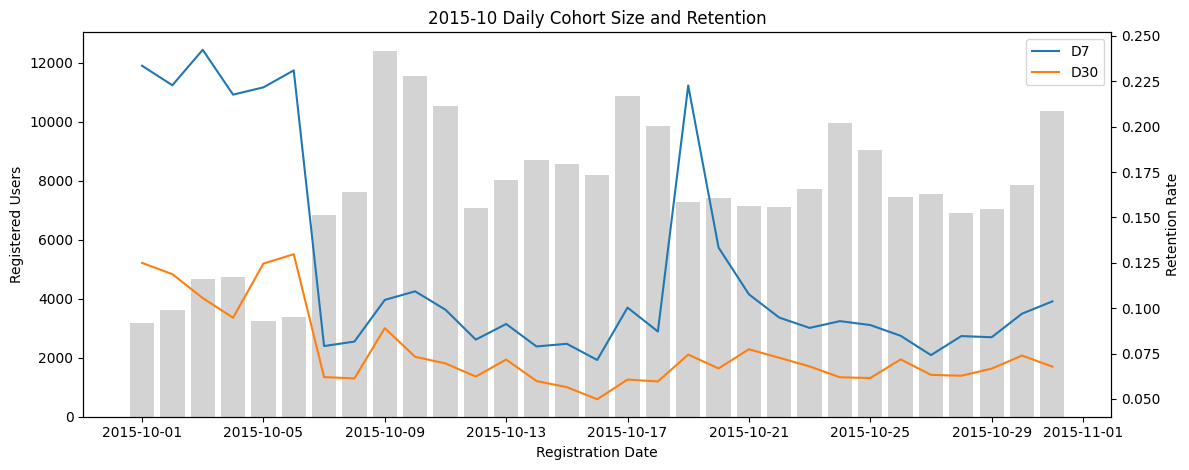

In [5]:
oct_daily=daily[daily.registration_date.dt.month.eq(10)]
fig,ax1=plt.subplots(figsize=(12,4.8)); ax1.bar(oct_daily.registration_date,oct_daily.registered_users,color='lightgray',label='Registered Users'); ax1.set(xlabel='Registration Date',ylabel='Registered Users',title='2015-10 Daily Cohort Size and Retention')
ax2=ax1.twinx(); ax2.plot(oct_daily.registration_date,oct_daily.d7_retention_rate,label='D7',color='tab:blue'); ax2.plot(oct_daily.registration_date,oct_daily.d30_retention_rate,label='D30',color='tab:orange'); ax2.set_ylabel('Retention Rate'); ax2.legend(); fig.tight_layout()
daily_plot_path=outputs_dir/'daily_cohort_retention.png'; fig.savefig(daily_plot_path,dpi=150); plt.show()

## 2. `registered_via` dimension

In [6]:
channel=base.groupby(['period_group','registered_via'],dropna=False).agg(registered_users=('msno','size'),d7_retention_rate=('d7_retained','mean'),d30_retention_rate=('d30_retained','mean')).reset_index()
channel['user_share']=channel.registered_users/channel.groupby('period_group').registered_users.transform('sum')
wide=channel.pivot(index='registered_via',columns='period_group',values=['registered_users','user_share','d7_retention_rate','d30_retention_rate']).fillna(0)
wide.columns=[f'{period}_{metric}' for metric,period in wide.columns]; wide=wide.reset_index()
baseline_months=3; wide['baseline_avg_monthly_users']=wide.baseline_registered_users/baseline_months; wide['registered_users_change']=wide.anomaly_registered_users-wide.baseline_avg_monthly_users
wide['user_share_change_pp']=wide.anomaly_user_share-wide.baseline_user_share; wide['d7_change_pp']=wide.anomaly_d7_retention_rate-wide.baseline_d7_retention_rate; wide['d30_change_pp']=wide.anomaly_d30_retention_rate-wide.baseline_d30_retention_rate
wide['within_d30_contribution_pp']=wide.anomaly_user_share*wide.d30_change_pp
baseline_overall=base[base.period_group.eq('baseline')].d30_retained.mean(); anomaly_overall=base[base.period_group.eq('anomaly')].d30_retained.mean(); counterfactual_structure=float((wide.anomaly_user_share*wide.baseline_d30_retention_rate).sum())
structure_effect=counterfactual_structure-baseline_overall; within_effect=anomaly_overall-counterfactual_structure
largest_structure=wide.loc[wide.registered_users_change.idxmax(),'registered_via']; meaningful=wide[(wide.baseline_registered_users>=1000)&(wide.anomaly_registered_users>=1000)].copy(); smallest_own_change=meaningful.loc[meaningful.d30_change_pp.idxmin(),'registered_via']; any_meaningful_decline=bool((meaningful.d30_change_pp<0).any()); focus_via=largest_structure
print('Channel comparison (baseline users are Jul-Sep total; change is anomaly minus baseline monthly average):'); print(wide.sort_values('registered_via').to_string(index=False))
print(f'\nBaseline D30={baseline_overall:.6f}; anomaly D30={anomaly_overall:.6f}; structure-only counterfactual={counterfactual_structure:.6f}')
print(f'Structure effect={structure_effect:.6f}; within-channel effect={within_effect:.6f}; total change={anomaly_overall-baseline_overall:.6f}')
print(f'Largest user-count structure increase and behavior focus: source {largest_structure}; any meaningful source D30 decline={any_meaningful_decline}; smallest meaningful own-source D30 change: source {smallest_own_change}')

Channel comparison (baseline users are Jul-Sep total; change is anomaly minus baseline monthly average):
 registered_via  anomaly_registered_users  baseline_registered_users  anomaly_user_share  baseline_user_share  anomaly_d7_retention_rate  baseline_d7_retention_rate  anomaly_d30_retention_rate  baseline_d30_retention_rate  baseline_avg_monthly_users  registered_users_change  user_share_change_pp  d7_change_pp  d30_change_pp  within_d30_contribution_pp
              2                      23.0                       99.0            0.000098             0.000252                   0.000000                    0.000000                    0.000000                     0.000000                   33.000000               -10.000000             -0.000155      0.000000       0.000000                    0.000000
              3                   20779.0                   187274.0            0.088090             0.477294                   0.205737                    0.253676                    0.0

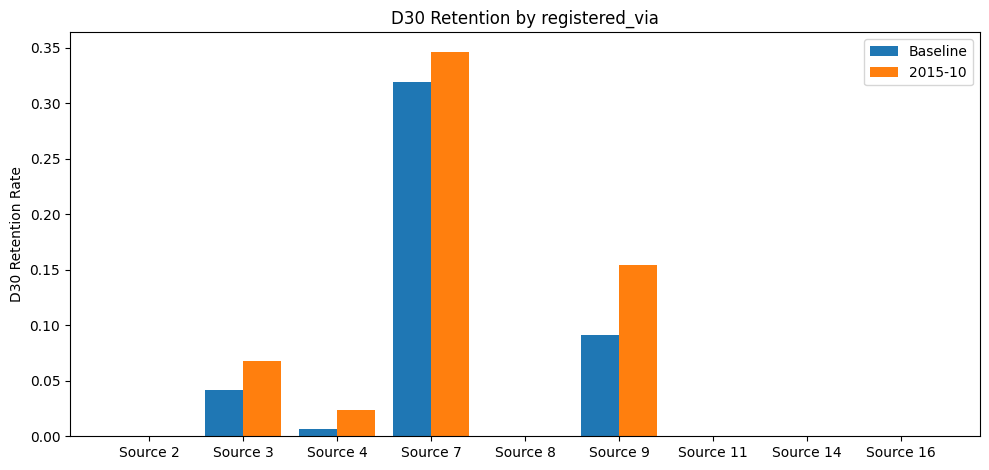

In [7]:
plot_wide=wide.sort_values('registered_via'); x=np.arange(len(plot_wide)); fig,ax=plt.subplots(figsize=(10,4.8)); ax.bar(x-.2,plot_wide.baseline_d30_retention_rate,.4,label='Baseline'); ax.bar(x+.2,plot_wide.anomaly_d30_retention_rate,.4,label='2015-10')
ax.set_xticks(x,[f'Source {v}' for v in plot_wide.registered_via]); ax.set(ylabel='D30 Retention Rate',title='D30 Retention by registered_via'); ax.legend(); fig.tight_layout()
channel_plot_path=outputs_dir/'channel_retention_comparison.png'; fig.savefig(channel_plot_path,dpi=150); plt.show()

## 3. Early-behavior dimension

In [8]:
behavior_metrics=['days_to_first_activity','first_7d_active_days','first_7d_total_secs','first_7d_num_100']
def behavior_summary(frame,label):
    parts=[]
    for period,g in frame.groupby('period_group',dropna=False):
        for metric in behavior_metrics:
            s=g[metric].dropna(); parts.append({'scope':label,'period_group':period,'metric':metric,'total_users':len(g),'observed_users':len(s),'mean':s.mean(),'median':s.median()})
        parts.append({'scope':label,'period_group':period,'metric':'d7_retention_rate','total_users':len(g),'observed_users':len(g),'mean':g.d7_retained.mean(),'median':np.nan})
        parts.append({'scope':label,'period_group':period,'metric':'d30_retention_rate','total_users':len(g),'observed_users':len(g),'mean':g.d30_retained.mean(),'median':np.nan})
    return pd.DataFrame(parts)
behavior=pd.concat([behavior_summary(base,'all_users'),behavior_summary(base[base.registered_via.eq(focus_via)],f'source_{focus_via}')],ignore_index=True)
behavior_wide=behavior.pivot(index=['scope','metric'],columns='period_group',values=['total_users','observed_users','mean','median']).reset_index()
print(f'Focus source selected by largest user-structure increase: source {focus_via}')
print(behavior.to_string(index=False))

Focus source selected by largest user-structure increase: source 4
    scope period_group                 metric  total_users  observed_users         mean    median
all_users      anomaly days_to_first_activity       235884          216333     7.620123    0.0000
all_users      anomaly   first_7d_active_days       235884          235884     2.125053    2.0000
all_users      anomaly    first_7d_total_secs       235884          235884  9982.572180 2155.4965
all_users      anomaly       first_7d_num_100       235884          235884    32.885677    5.0000
all_users      anomaly      d7_retention_rate       235884          235884     0.109757       NaN
all_users      anomaly     d30_retention_rate       235884          235884     0.071501       NaN
all_users     baseline days_to_first_activity       392366          371585     8.437111    0.0000
all_users     baseline   first_7d_active_days       392366          392366     2.446682    2.0000
all_users     baseline    first_7d_total_secs      

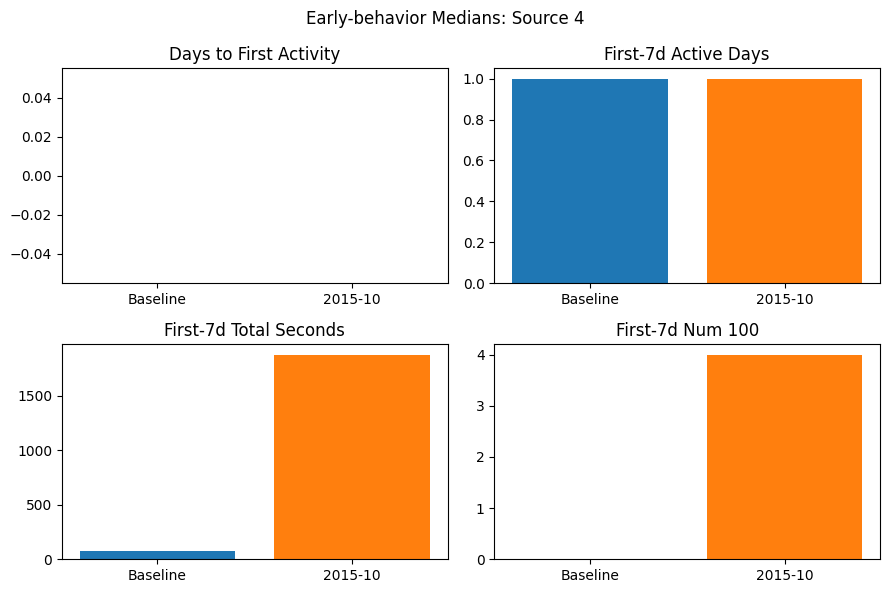

In [9]:
focus_behavior=behavior[(behavior.scope.eq(f'source_{focus_via}'))&behavior.metric.isin(behavior_metrics)].pivot(index='metric',columns='period_group',values='median').reindex(behavior_metrics)
fig,axes=plt.subplots(2,2,figsize=(9,6)); labels=['Days to First Activity','First-7d Active Days','First-7d Total Seconds','First-7d Num 100']
for ax,metric,label in zip(axes.ravel(),behavior_metrics,labels): vals=pd.to_numeric(focus_behavior.loc[metric,['baseline','anomaly']],errors='coerce').fillna(0).to_numpy(dtype=float); ax.bar(['Baseline','2015-10'],vals,color=['tab:blue','tab:orange']); ax.set_title(label)
fig.suptitle(f'Early-behavior Medians: Source {focus_via}'); fig.tight_layout(); behavior_plot_path=outputs_dir/'early_behavior_comparison.png'; fig.savefig(behavior_plot_path,dpi=150); plt.show()

In [10]:
raw_after={p.name:(p.stat().st_size,p.stat().st_mtime_ns) for p in raw_files}; raw_unchanged=raw_before==raw_after; runtime=time.perf_counter()-run_started
print(f'Base: {base_path} ({len(base):,} rows; {base_path.stat().st_size:,} bytes)')
print(f'Plots: {daily_plot_path}; {channel_plot_path}; {behavior_plot_path}')
print(f'Total runtime: {runtime:.2f} seconds ({runtime/60:.2f} minutes); raw unchanged={raw_unchanged}')
assert raw_unchanged

Base: ./data/processed/new_user_anomaly_base.csv (628,250 rows; 66,045,125 bytes)
Plots: ./outputs/daily_cohort_retention.png; ./outputs/channel_retention_comparison.png; ./outputs/early_behavior_comparison.png
Total runtime: 304.98 seconds (5.08 minutes); raw unchanged=True


## 教程式结论与下一步

### A. 时间维度

10月1日至6日：新增用户22,771，日均3,795，D7为22.83%，D30为11.44%。10月7日至31日：新增用户213,113，日均8,525，D7为9.71%，D30为6.69%。异常断点集中在10月7日前后。

### B. 来源维度

来源4占比从7月至9月基准期的0.12%、10月1日至6日的0.59%，跃升至10月7日至31日的80.83%。留存下降与来源4大规模进入在时间上高度同步，但此处仍不是因果结论。

### C. 行为维度

10月7日至31日来源4首7天活跃天数为1.99、播放秒数8,306.93、完整播放27.17次，D7为5.09%、D30为2.37%；首次活动覆盖率仍约90.60%。因此，来源4并非无法产生首次活动，其主要特征是首次活动后的首周持续使用深度较弱。

**下一步：**提出来源结构、早期使用和订阅质量假设，并使用行为与交易数据验证。
